In [1]:
import pandas as pd
import numpy as np
import optuna
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

c:\Users\Manmeet\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data = datasets.load_wine()
X = data.data
y = data.target

# Scale data
scaler = StandardScaler()
X = scaler.fit_transform(X)

results = []
best_convergence = []

In [3]:
def objective(trial):
    C = trial.suggest_float("C", 0.1, 100)
    gamma = trial.suggest_float("gamma", 0.001, 1)
    kernel = trial.suggest_categorical("kernel", ["linear", "rbf", "poly"])

    model = SVC(C=C, gamma=gamma, kernel=kernel)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    return acc

In [4]:
for i in range(10):
    print(f"\nRunning Sample {i+1}")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=i
    )

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=100)

    best_trial = study.best_trial

    results.append({
        "Sample": f"S{i+1}",
        "Accuracy": best_trial.value,
        "Kernel": best_trial.params["kernel"],
        "C": best_trial.params["C"],
        "Gamma": best_trial.params["gamma"]
    })

    # Store best convergence
    if i == 0 or best_trial.value > max([r["Accuracy"] for r in results[:-1]]):
        best_convergence = [t.value for t in study.trials]

[I 2026-04-30 23:44:57,239] A new study created in memory with name: no-name-627e89d1-b8ae-4442-8f8b-8f7ee9a91f95
[I 2026-04-30 23:44:57,282] Trial 0 finished with value: 1.0 and parameters: {'C': 85.98199027023607, 'gamma': 0.03698397861165568, 'kernel': 'rbf'}. Best is trial 0 with value: 1.0.
[I 2026-04-30 23:44:57,300] Trial 1 finished with value: 1.0 and parameters: {'C': 1.094241110249178, 'gamma': 0.06411253455003627, 'kernel': 'rbf'}. Best is trial 0 with value: 1.0.
[I 2026-04-30 23:44:57,314] Trial 2 finished with value: 1.0 and parameters: {'C': 94.83532943277726, 'gamma': 0.3883985413087162, 'kernel': 'linear'}. Best is trial 0 with value: 1.0.
[I 2026-04-30 23:44:57,328] Trial 3 finished with value: 0.6296296296296297 and parameters: {'C': 13.243825988726552, 'gamma': 0.9866354138529477, 'kernel': 'rbf'}. Best is trial 0 with value: 1.0.
[I 2026-04-30 23:44:57,358] Trial 4 finished with value: 0.9629629629629629 and parameters: {'C': 88.21747246250673, 'gamma': 0.435989655


Running Sample 1


[I 2026-04-30 23:44:57,469] Trial 10 finished with value: 1.0 and parameters: {'C': 35.72267882718813, 'gamma': 0.026968096140019326, 'kernel': 'linear'}. Best is trial 0 with value: 1.0.
[I 2026-04-30 23:44:57,489] Trial 11 finished with value: 0.9814814814814815 and parameters: {'C': 36.763278815590944, 'gamma': 0.009058326434888186, 'kernel': 'rbf'}. Best is trial 0 with value: 1.0.
[I 2026-04-30 23:44:57,509] Trial 12 finished with value: 1.0 and parameters: {'C': 67.66533541769994, 'gamma': 0.19824612807491143, 'kernel': 'rbf'}. Best is trial 0 with value: 1.0.
[I 2026-04-30 23:44:57,559] Trial 13 finished with value: 1.0 and parameters: {'C': 76.31033433740438, 'gamma': 0.18505331352391988, 'kernel': 'rbf'}. Best is trial 0 with value: 1.0.
[I 2026-04-30 23:44:57,596] Trial 14 finished with value: 0.8333333333333334 and parameters: {'C': 38.672245499355306, 'gamma': 0.7479034480224236, 'kernel': 'rbf'}. Best is trial 0 with value: 1.0.
[I 2026-04-30 23:44:57,622] Trial 15 finishe


Running Sample 2


[I 2026-04-30 23:45:00,311] Trial 11 finished with value: 1.0 and parameters: {'C': 70.68244760052997, 'gamma': 0.2771852219106106, 'kernel': 'linear'}. Best is trial 7 with value: 1.0.
[I 2026-04-30 23:45:00,337] Trial 12 finished with value: 1.0 and parameters: {'C': 65.38066982975529, 'gamma': 0.29129036664727365, 'kernel': 'linear'}. Best is trial 7 with value: 1.0.
[I 2026-04-30 23:45:00,373] Trial 13 finished with value: 1.0 and parameters: {'C': 76.22767430911792, 'gamma': 0.022881446454668664, 'kernel': 'linear'}. Best is trial 7 with value: 1.0.
[I 2026-04-30 23:45:00,391] Trial 14 finished with value: 1.0 and parameters: {'C': 60.5618101534136, 'gamma': 0.3712772063534265, 'kernel': 'linear'}. Best is trial 7 with value: 1.0.
[I 2026-04-30 23:45:00,424] Trial 15 finished with value: 1.0 and parameters: {'C': 85.83714572746928, 'gamma': 0.5921592769594517, 'kernel': 'linear'}. Best is trial 7 with value: 1.0.
[I 2026-04-30 23:45:00,449] Trial 16 finished with value: 1.0 and pa

...

[I 2026-04-30 23:45:08,654] Trial 21 finished with value: 1.0 and parameters: {'C': 36.995098378072235, 'gamma': 0.24702479142174483, 'kernel': 'rbf'}. Best is trial 9 with value: 1.0.
[I 2026-04-30 23:45:08,654] Trial 22 finished with value: 0.9444444444444444 and parameters: {'C': 21.793578675334434, 'gamma': 0.0038978349472703067, 'kernel': 'rbf'}. Best is trial 9 with value: 1.0.
[I 2026-04-30 23:45:08,671] Trial 23 finished with value: 1.0 and parameters: {'C': 42.91398350384036, 'gamma': 0.18132833406911825, 'kernel': 'rbf'}. Best is trial 9 with value: 1.0.
[I 2026-04-30 23:45:08,688] Trial 24 finished with value: 1.0 and parameters: {'C': 67.0235536201698, 'gamma': 0.29417520190142227, 'kernel': 'rbf'}. Best is trial 9 with value: 1.0.
[I 2026-04-30 23:45:08,688] Trial 25 finished with value: 0.9814814814814815 and parameters: {'C': 49.88589806435595, 'gamma': 0.10244554895328428, 'kernel': 'rbf'}. Best is trial 9 with value: 1.0.
[I 2026-04-30 23:45:08,705] Trial 26 finished w


Running Sample 9


[I 2026-04-30 23:45:09,703] Trial 24 finished with value: 0.9444444444444444 and parameters: {'C': 44.653420857693796, 'gamma': 0.014237860708333137, 'kernel': 'rbf'}. Best is trial 23 with value: 0.9814814814814815.
[I 2026-04-30 23:45:09,711] Trial 25 finished with value: 0.9629629629629629 and parameters: {'C': 26.91402089514831, 'gamma': 0.7123445137663003, 'kernel': 'linear'}. Best is trial 23 with value: 0.9814814814814815.
[I 2026-04-30 23:45:09,719] Trial 26 finished with value: 0.8888888888888888 and parameters: {'C': 63.065270833139444, 'gamma': 0.33994467767338254, 'kernel': 'rbf'}. Best is trial 23 with value: 0.9814814814814815.
[I 2026-04-30 23:45:09,727] Trial 27 finished with value: 0.9629629629629629 and parameters: {'C': 40.116745980886336, 'gamma': 0.4594332421967462, 'kernel': 'linear'}. Best is trial 23 with value: 0.9814814814814815.
[I 2026-04-30 23:45:09,740] Trial 28 finished with value: 0.7407407407407407 and parameters: {'C': 98.29809561335576, 'gamma': 0.753


Running Sample 10


[I 2026-04-30 23:45:10,664] Trial 26 finished with value: 0.9629629629629629 and parameters: {'C': 0.6136424942003598, 'gamma': 0.42151458138114795, 'kernel': 'poly'}. Best is trial 13 with value: 1.0.
[I 2026-04-30 23:45:10,672] Trial 27 finished with value: 0.9629629629629629 and parameters: {'C': 10.139303489896008, 'gamma': 0.18651822613426622, 'kernel': 'poly'}. Best is trial 13 with value: 1.0.
[I 2026-04-30 23:45:10,681] Trial 28 finished with value: 0.9814814814814815 and parameters: {'C': 23.881145328146417, 'gamma': 0.06772668082350547, 'kernel': 'linear'}. Best is trial 13 with value: 1.0.
[I 2026-04-30 23:45:10,689] Trial 29 finished with value: 0.9629629629629629 and parameters: {'C': 37.9432752015685, 'gamma': 0.2847589798611717, 'kernel': 'poly'}. Best is trial 13 with value: 1.0.
[I 2026-04-30 23:45:10,697] Trial 30 finished with value: 1.0 and parameters: {'C': 54.71180982427004, 'gamma': 0.014396636912227812, 'kernel': 'rbf'}. Best is trial 13 with value: 1.0.
[I 2026

In [5]:
df = pd.DataFrame(results)
df.to_csv("results.csv", index=False)
print("\nFinal Results:\n", df)


Final Results:
   Sample  Accuracy  Kernel          C     Gamma
0     S1  1.000000     rbf  85.981990  0.036984
1     S2  1.000000  linear  68.746561  0.186704
2     S3  0.981481  linear  15.105570  0.556020
3     S4  0.981481  linear  79.383739  0.108295
4     S5  0.981481  linear  88.052180  0.527690
5     S6  0.981481     rbf   1.408324  0.100763
6     S7  1.000000    poly  44.406228  0.893401
7     S8  1.000000     rbf  74.190742  0.186312
8     S9  0.981481     rbf  44.894347  0.002177
9    S10  1.000000    poly  19.662932  0.043765


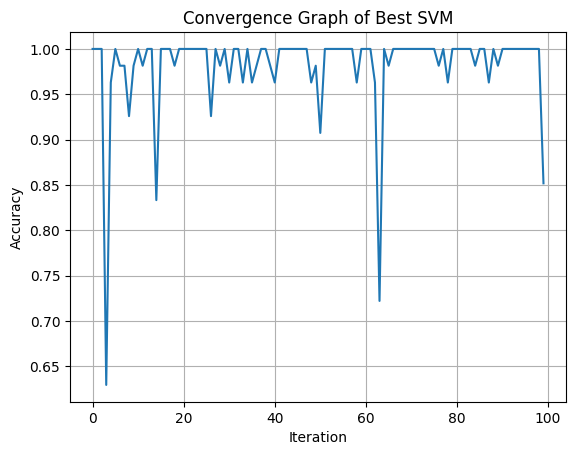

In [6]:
plt.plot(best_convergence)
plt.xlabel("Iteration")
plt.ylabel("Accuracy")
plt.title("Convergence Graph of Best SVM")
plt.grid()
plt.savefig("convergence.png")
plt.show()